# Binary Log Analysis — Event Distributions & Reaccess Probability

Analyzes the kernel trace binary logs (access, insertion, eviction) from a
LearnedCache workload run.  Produces three families of plots:

1. **Temporal distribution** of insertions, accesses, and evictions on one graph.
2. **Reaccess probability** — how likely is a cached page to be accessed again?
3. **Reaccess probability given position** — does a page's position (percentile)
   in the insertion (or first-access) stream predict whether it will be reaccessed?

Change `DATA_DIR` and `WORKLOAD` in the cell below to analyze different data.

In [17]:
# ============================================================================
# Configuration — point this at your binary log directory
# ============================================================================
DATA_DIR = "../data/tracer-bundle-jun-11/cache_ext_logs"
WORKLOAD = "ycsb_b"                         # change to ycsb_c, ycsb_e, etc.
N_PERCENTILE_BINS = 10                       # granularity for position-based plots

# ============================================================================
# Imports
# ============================================================================
import numpy as np
from pathlib import Path
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict
import bisect
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print(f"Data dir : {DATA_DIR}")
print(f"Workload : {WORKLOAD}")

Data dir : ../data/tracer-bundle-jun-11/cache_ext_logs
Workload : ycsb_b


In [18]:
# ============================================================================
# Binary record formats (must match kernel tracepoint / read_binary_logs.py)
# ============================================================================

# 88-byte cache_access event
ACCESS_DTYPE = np.dtype([
    ("ts", "<u8"),   # timestamp (ns)
    ("pd", "<u8"),   # page_time_delta
    ("p2", "<u8"),   # page_time_delta2
    ("id", "<u8"),   # inode_time_delta
    ("i2", "<u8"),   # inode_time_delta2
    ("dm", "<u4"),   # major device
    ("dn", "<u4"),   # minor device
    ("in", "<u8"),   # inode number
    ("of", "<u8"),   # page offset / index
    ("sd", "<u4"),   # seq_distance
    ("_pad", "<u4"), # alignment padding
    ("sz", "<u8"),   # file size
    ("fq", "<u4"),   # frequency
    ("ie", "<u4"),   # inode hotness EMA
])

# 8-byte cache_eviction event
EVICTION_DTYPE = np.dtype([("ts", "<u8")])

# 32-byte cache_insertion event (struct: <QIIQQ)
INSERTION_DTYPE = np.dtype([
    ("ts", "<u8"),   # timestamp (ns)
    ("dm", "<u4"),   # major device
    ("dn", "<u4"),   # minor device
    ("in", "<u8"),   # inode number
    ("ix", "<u8"),   # page index (≡ offset >> PAGE_SHIFT)
])

# ---------------------------------------------------------------------------
def load_workload(data_dir: str, workload: str):
    """Memory-map the access, eviction, and insertion binary logs for a workload."""
    wdir = Path(data_dir) / workload
    iter_dirs = sorted(wdir.glob("iter_*"))
    if not iter_dirs:
        raise FileNotFoundError(f"No iter_* directories in {wdir}")

    it = iter_dirs[0]  # first iteration

    af = sorted(glob.glob(str(it / "mglru_lc_access_*.bin")))
    ef = sorted(glob.glob(str(it / "mglru_lc_eviction_*.bin")))
    inf = sorted(glob.glob(str(it / "mglru_lc_insertion_*.bin")))

    if not (len(af) == len(ef) == len(inf) == 1):
        raise FileNotFoundError(
            f"Expected 1 of each log type; got a={len(af)} e={len(ef)} i={len(inf)}"
        )

    access    = np.memmap(af[0],  dtype=ACCESS_DTYPE,    mode="r")
    eviction  = np.memmap(ef[0],  dtype=EVICTION_DTYPE,  mode="r")
    insertion = np.memmap(inf[0], dtype=INSERTION_DTYPE, mode="r")

    return access, eviction, insertion

# ---------------------------------------------------------------------------
access, eviction, insertion = load_workload(DATA_DIR, WORKLOAD)

print(f"Access records    : {len(access):>12,}")
print(f"Eviction records  : {len(eviction):>12,}")
print(f"Insertion records : {len(insertion):>12,}")

Access records    :   39,831,444
Eviction records  :      321,164
Insertion records :   13,718,036


---
## 1. Temporal Distribution of Insertions, Accesses, and Evictions

Overlapping histograms showing when each event type occurs during the workload.

Workload duration  : 317.7 s  (5.3 min)
Access event rate  : 125,374 events/s
Eviction event rate: 1,011 events/s
Insertion event rate: 43,179 events/s


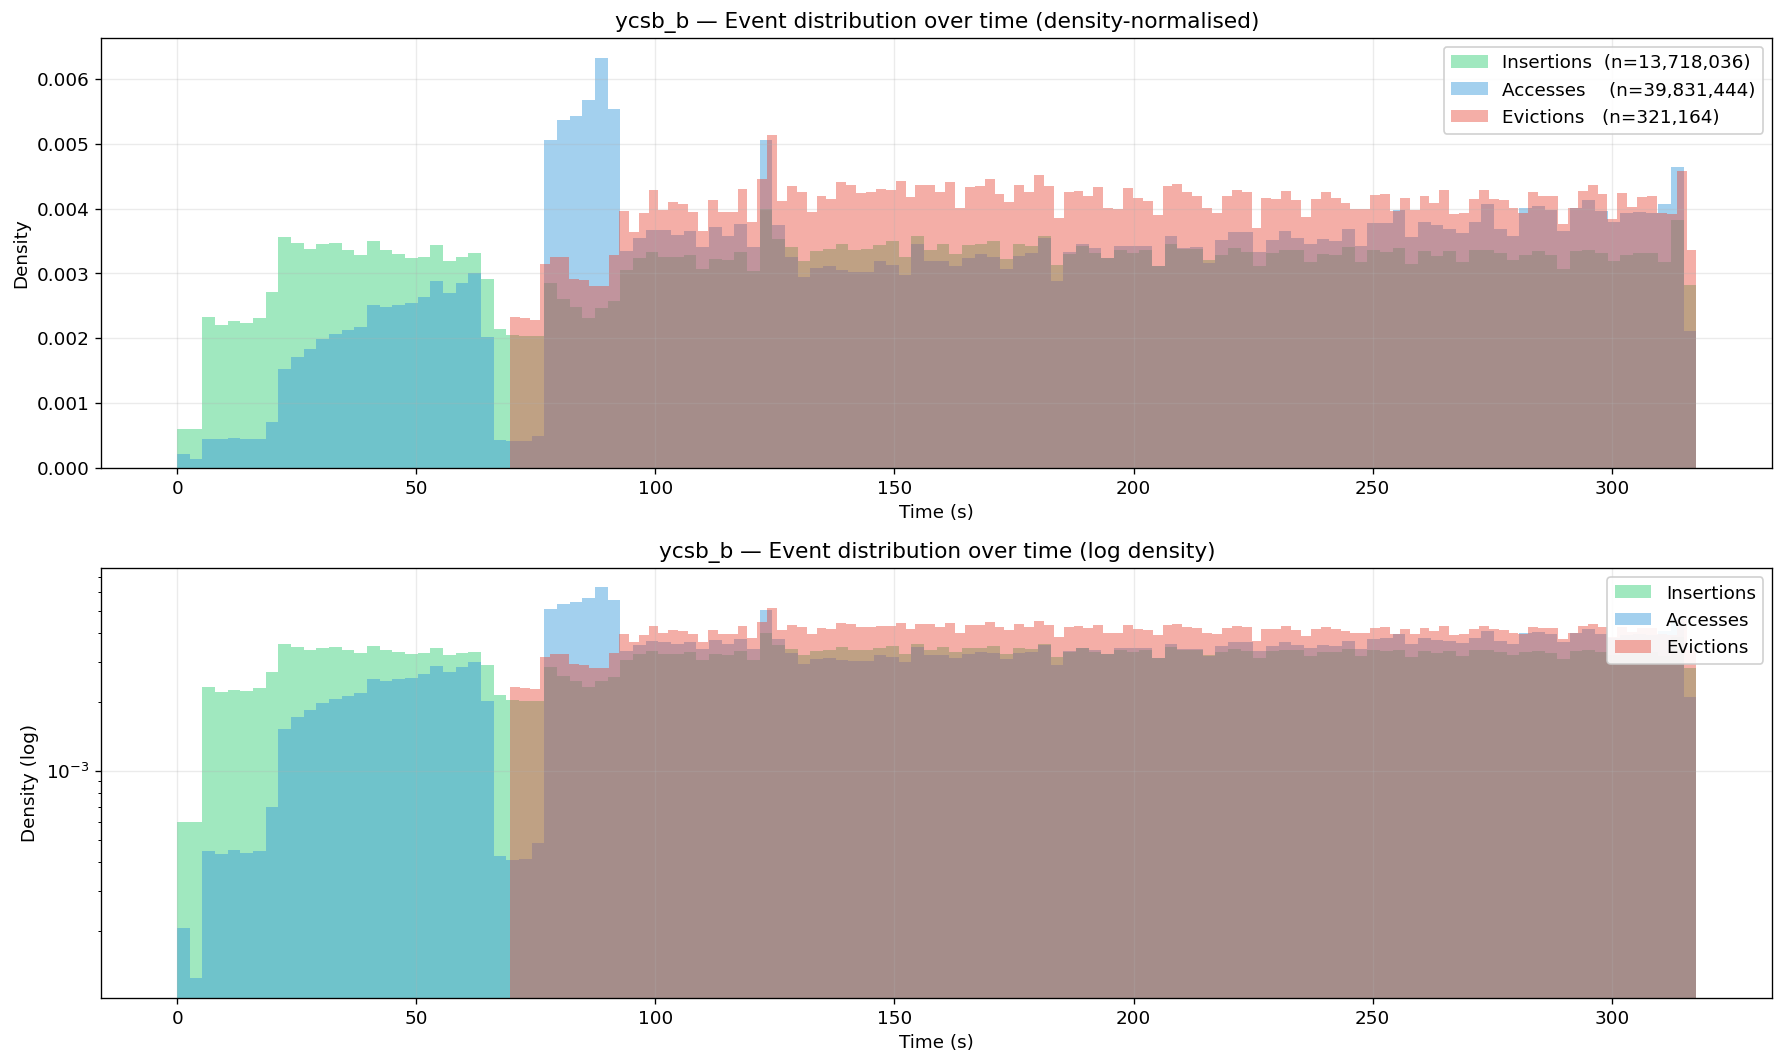

In [19]:
# ---- Normalise timestamps to seconds from first event --------------------
t0 = min(access["ts"][0], eviction["ts"][0], insertion["ts"][0])

acc_ts  = (access["ts"]    - t0) / 1e9   # seconds
evc_ts  = (eviction["ts"]  - t0) / 1e9
ins_ts  = (insertion["ts"] - t0) / 1e9

# ---- Shared time range --------------------------------------------------
t_min = 0.0
t_max = max(acc_ts.max(), evc_ts.max(), ins_ts.max())

print(f"Workload duration  : {t_max:.1f} s  ({t_max/60:.1f} min)")
print(f"Access event rate  : {len(acc_ts)/t_max:,.0f} events/s")
print(f"Eviction event rate: {len(evc_ts)/t_max:,.0f} events/s")
print(f"Insertion event rate: {len(ins_ts)/t_max:,.0f} events/s")

# ---- Plot ---------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

bins = 120

# Top: overlapping histograms (density-normalised)
ax = axes[0]
ax.hist(ins_ts, bins=bins, alpha=0.45, density=True,
        color="#2ecc71", label=f"Insertions  (n={len(ins_ts):,})")
ax.hist(acc_ts, bins=bins, alpha=0.45, density=True,
        color="#3498db", label=f"Accesses    (n={len(acc_ts):,})")
ax.hist(evc_ts, bins=bins, alpha=0.45, density=True,
        color="#e74c3c", label=f"Evictions   (n={len(evc_ts):,})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Density")
ax.set_title(f"{WORKLOAD} — Event distribution over time (density-normalised)")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, alpha=0.25)

# Bottom: log-scale to highlight relative shape
ax = axes[1]
ax.hist(ins_ts, bins=bins, alpha=0.45, density=True,
        color="#2ecc71", label="Insertions")
ax.hist(acc_ts, bins=bins, alpha=0.45, density=True,
        color="#3498db", label="Accesses")
ax.hist(evc_ts, bins=bins, alpha=0.45, density=True,
        color="#e74c3c", label="Evictions")
ax.set_yscale("log")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Density (log)")
ax.set_title(f"{WORKLOAD} — Event distribution over time (log density)")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

---
## 2. Reaccess Probability of a Page

A **page** is identified by the 4-tuple `(dm, dn, ino, offset)`.  For each
unique page that appears in the access log we count how many access events it
receives.  The **reaccess probability** is the fraction of unique pages that
are accessed *more than once*.

In [20]:
# ---- Extract page keys as structured array for vectorised unique ---------
page_key_dtype = np.dtype([("dm", "u4"), ("dn", "u4"), ("in", "u8"), ("of", "u8")])
page_keys = np.empty(len(access), dtype=page_key_dtype)
page_keys["dm"] = access["dm"]
page_keys["dn"] = access["dn"]
page_keys["in"] = access["in"]
page_keys["of"] = access["of"]

# Count occurrences of each unique page
unique_keys, inverse, counts = np.unique(
    page_keys, return_inverse=True, return_counts=True
)

n_total      = len(unique_keys)
n_single     = int(np.sum(counts == 1))
n_reaccessed = int(np.sum(counts >= 2))

print(f"Total unique pages  : {n_total:>12,}")
print(f"Accessed exactly once: {n_single:>12,}  ({n_single/n_total*100:5.1f}%)")
print(f"Accessed 2+ times   : {n_reaccessed:>12,}  ({n_reaccessed/n_total*100:5.1f}%)")
print(f"→ Reaccess probability = {n_reaccessed/n_total:.4f}")
print(f"Total access events   : {len(access):>12,}")

Total unique pages  :    7,973,460
Accessed exactly once:    6,021,792  ( 75.5%)
Accessed 2+ times   :    1,951,668  ( 24.5%)
→ Reaccess probability = 0.2448
Total access events   :   39,831,444


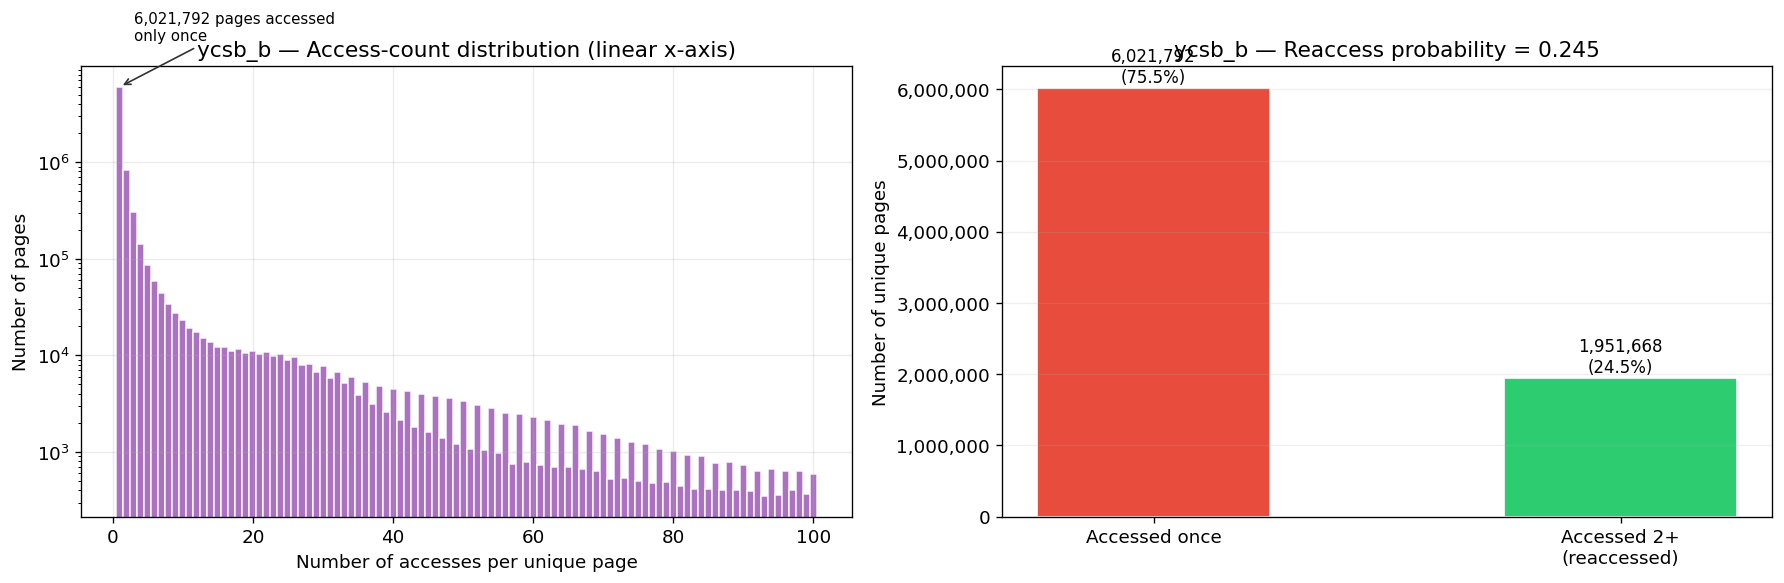

In [21]:
# ---- Figure: reaccess count distribution + summary bar -------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: histogram of access-count-per-page (log-log)
ax = axes[0]
max_count = int(counts.max())
bins = np.arange(1, min(max_count, 100) + 2) - 0.5  # bin edges for small counts
ax.hist(counts, bins=bins, color="#9b59b6", edgecolor="white", alpha=0.85)
ax.set_xlabel("Number of accesses per unique page")
ax.set_ylabel("Number of pages")
ax.set_title(f"{WORKLOAD} — Access-count distribution (linear x-axis)")
ax.set_yscale("log")
ax.grid(True, alpha=0.25)

# Annotate
ax.annotate(f"{n_single:,} pages accessed\nonly once",
            xy=(1, n_single), xytext=(3, n_single * 3),
            arrowprops=dict(arrowstyle="->", color="#333"), fontsize=9)

# Right: reaccess probability pie/bar
ax = axes[1]
bars = ax.bar(["Accessed once", "Accessed 2+\n(reaccessed)"],
              [n_single, n_reaccessed],
              color=["#e74c3c", "#2ecc71"], edgecolor="white", width=0.5)
for bar, val in zip(bars, [n_single, n_reaccessed]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + n_total * 0.01,
            f"{val:,}\n({val/n_total*100:.1f}%)", ha="center", fontsize=10)
ax.set_ylabel("Number of unique pages")
ax.set_title(f"{WORKLOAD} — Reaccess probability = {n_reaccessed/n_total:.3f}")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.show()

---
## 3. Reaccess Probability Given Position in the Event Distribution

Does a page's position (early vs. late) in the **insertion** or **first-access**
stream predict whether it will be reaccessed later?

We split each event stream into `N_PERCENTILE_BINS` equal-width groups by
timestamp order (0–10% earliest events, 10–20%, …, 90–100% latest) and
compute the fraction of pages in each bin that are reaccessed **after** the
event of interest (only forward-looking).

In [22]:
# ============================================================================
# Pre-compute a page → sorted-access-timestamps lookup once.
# This is the expensive step; everything downstream reuses it.
# ============================================================================

def build_page_ts_dict(records, dm_f="dm", dn_f="dn", in_f="in", of_f="of", ts_f="ts"):
    """Return { (dm, dn, ino, offset): np.array(sorted_timestamps) }."""
    d = defaultdict(list)
    N = len(records)
    chunk = max(1, N // 10)
    for i in range(N):
        key = (int(records[dm_f][i]), int(records[dn_f][i]),
               int(records[in_f][i]), int(records[of_f][i]))
        d[key].append(int(records[ts_f][i]))
        if (i + 1) % chunk == 0:
            print(f"  ... {i+1:,}/{N:,} records processed ({(i+1)/N*100:.0f}%)")
    # Sort the timestamp lists in-place
    for k in d:
        d[k] = np.array(sorted(d[k]), dtype=np.uint64)
    return d

print("Building page → access-timestamp lookup ...")
page_access_ts = build_page_ts_dict(access,
    dm_f="dm", dn_f="dn", in_f="in", of_f="of", ts_f="ts")
print(f"Done — {len(page_access_ts):,} unique pages indexed.")

Building page → access-timestamp lookup ...
  ... 3,983,144/39,831,444 records processed (10%)
  ... 7,966,288/39,831,444 records processed (20%)
  ... 11,949,432/39,831,444 records processed (30%)
  ... 15,932,576/39,831,444 records processed (40%)
  ... 19,915,720/39,831,444 records processed (50%)
  ... 23,898,864/39,831,444 records processed (60%)
  ... 27,882,008/39,831,444 records processed (70%)
  ... 31,865,152/39,831,444 records processed (80%)
  ... 35,848,296/39,831,444 records processed (90%)
  ... 39,831,440/39,831,444 records processed (100%)
Done — 7,973,460 unique pages indexed.


In [23]:
# ============================================================================
# Reaccess probability given insertion percentile
# "Reaccessed" = page appears in the access log at least once AFTER its
# insertion timestamp.
# ============================================================================

def reaccess_prob_by_insertion_pct(insertion, page_access_ts, n_bins=10):
    """Return (probabilities, bin_labels) for insertion-percentile reaccess."""
    # Sort by insertion timestamp
    sort_idx = np.argsort(insertion["ts"])
    N = len(sort_idx)
    bin_edges = np.linspace(0, N, n_bins + 1, dtype=int)

    probs, labels, counts = [], [], []
    for i in range(n_bins):
        start, end = bin_edges[i], bin_edges[i + 1]
        if start >= end:
            continue

        n_reaccessed = 0
        for j in range(start, end):
            idx = sort_idx[j]
            key = (int(insertion["dm"][idx]), int(insertion["dn"][idx]),
                   int(insertion["in"][idx]), int(insertion["ix"][idx]))
            ins_ts = int(insertion["ts"][idx])
            ts_arr = page_access_ts.get(key)
            if ts_arr is not None:
                # Check if any access timestamp > insertion timestamp
                pos = np.searchsorted(ts_arr, ins_ts, side="right")
                if pos < len(ts_arr):
                    n_reaccessed += 1

        bin_n = end - start
        probs.append(n_reaccessed / bin_n)
        counts.append(bin_n)
        pct_lo = i * 100 / n_bins
        pct_hi = (i + 1) * 100 / n_bins
        labels.append(f"{pct_lo:.0f}–{pct_hi:.0f}%")

    return np.array(probs), labels, np.array(counts)

print("Computing reaccess probability by insertion percentile ...")
ins_probs, ins_labels, ins_counts = reaccess_prob_by_insertion_pct(
    insertion, page_access_ts, N_PERCENTILE_BINS
)
print("Done.")

Computing reaccess probability by insertion percentile ...
Done.


In [24]:
# ============================================================================
# Reaccess probability given first-access percentile
# "Reaccessed" = page appears in the access log at least TWICE, with the
# second (or later) access after the page's first access.
# ============================================================================

def reaccess_prob_by_first_access_pct(access, page_access_ts, n_bins=10):
    """Return (probabilities, bin_labels) for first-access-percentile reaccess."""
    # Build a list of (first_access_ts, page_key) for every unique page
    page_first_ts = {}   # key -> first access timestamp
    for k, ts_arr in page_access_ts.items():
        page_first_ts[k] = ts_arr[0]  # timestamps are already sorted

    # Sort pages by first-access time
    sorted_pages = sorted(page_first_ts.items(), key=lambda x: x[1])
    N = len(sorted_pages)
    bin_edges = np.linspace(0, N, n_bins + 1, dtype=int)

    probs, labels, counts = [], [], []
    for i in range(n_bins):
        start, end = bin_edges[i], bin_edges[i + 1]
        if start >= end:
            continue

        n_reaccessed = 0
        for j in range(start, end):
            key, first_ts = sorted_pages[j]
            ts_arr = page_access_ts[key]
            # Reaccessed if there's any access timestamp > first_ts
            pos = np.searchsorted(ts_arr, first_ts, side="right")
            if pos < len(ts_arr):
                n_reaccessed += 1

        bin_n = end - start
        probs.append(n_reaccessed / bin_n)
        counts.append(bin_n)
        pct_lo = i * 100 / n_bins
        pct_hi = (i + 1) * 100 / n_bins
        labels.append(f"{pct_lo:.0f}–{pct_hi:.0f}%")

    return np.array(probs), labels, np.array(counts)

print("Computing reaccess probability by first-access percentile ...")
acc_probs, acc_labels, acc_counts = reaccess_prob_by_first_access_pct(
    access, page_access_ts, N_PERCENTILE_BINS
)
print("Done.")

Computing reaccess probability by first-access percentile ...
Done.


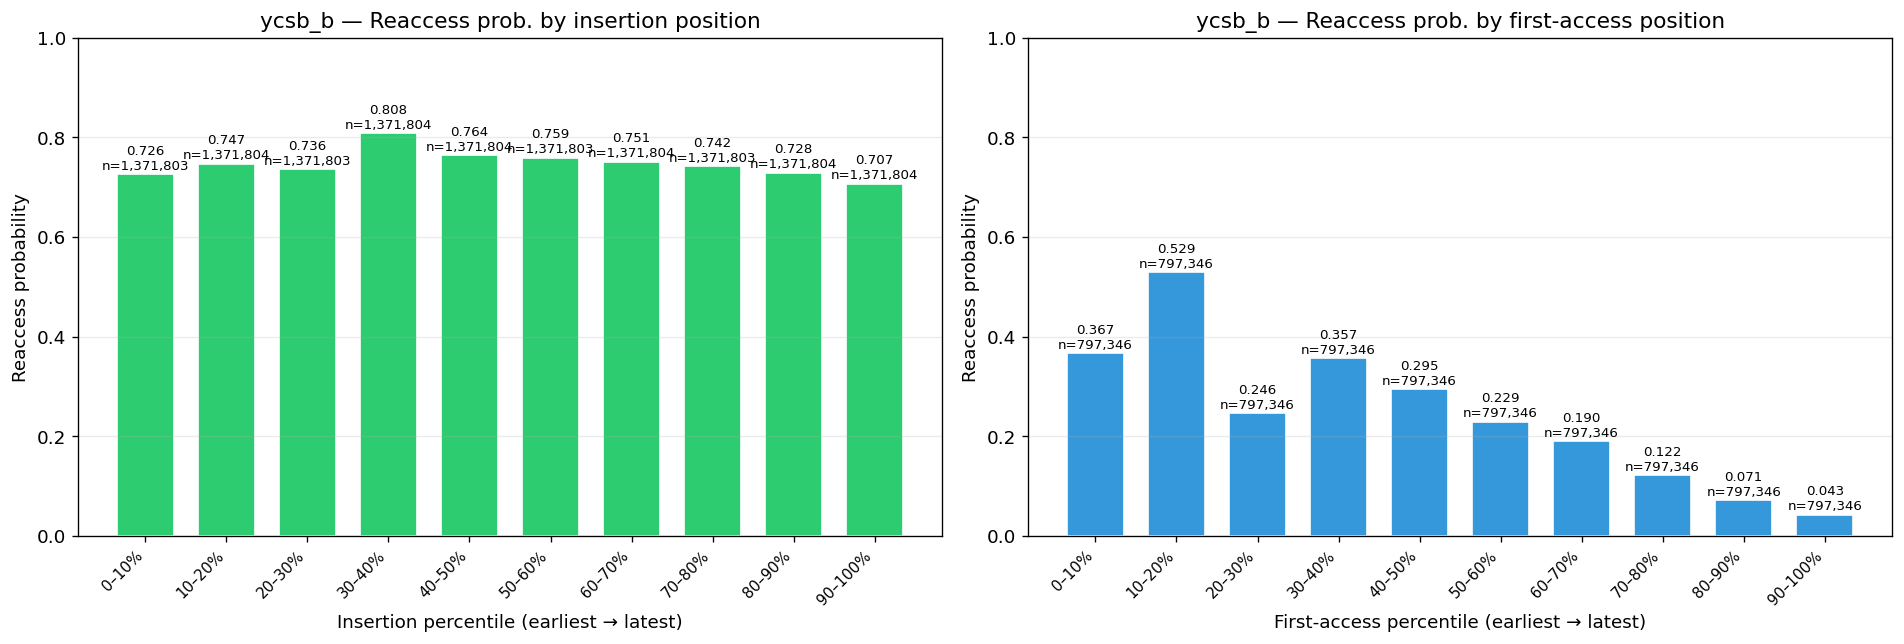


         Bin    Ins Reaccess       N_ins    Acc Reaccess     N_pages
------------------------------------------------------------------------
       0–10%          0.7258   1,371,803          0.3667     797,346
      10–20%          0.7467   1,371,804          0.5288     797,346
      20–30%          0.7360   1,371,803          0.2461     797,346
      30–40%          0.8077   1,371,804          0.3568     797,346
      40–50%          0.7642   1,371,804          0.2947     797,346
      50–60%          0.7587   1,371,803          0.2291     797,346
      60–70%          0.7506   1,371,804          0.1898     797,346
      70–80%          0.7420   1,371,803          0.1218     797,346
      80–90%          0.7283   1,371,804          0.0713     797,346
     90–100%          0.7070   1,371,804          0.0426     797,346
     Overall          0.7467  13,718,036          0.2448   7,973,460


In [25]:
# ---- Combined figure: insertion + first-access reaccess-by-position ------
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Left: reaccess probability given insertion percentile
ax = axes[0]
x = np.arange(len(ins_probs))
bars = ax.bar(x, ins_probs, color="#2ecc71", edgecolor="white", width=0.7)
ax.set_xticks(x)
ax.set_xticklabels(ins_labels, rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, max(1.0, ins_probs.max() * 1.15))
ax.set_ylabel("Reaccess probability")
ax.set_xlabel("Insertion percentile (earliest → latest)")
ax.set_title(f"{WORKLOAD} — Reaccess prob. by insertion position")
ax.grid(True, alpha=0.25, axis="y")

# Annotate bars with the probability
for bar, prob, cnt in zip(bars, ins_probs, ins_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{prob:.3f}\nn={cnt:,}", ha="center", fontsize=8)

# Right: reaccess probability given first-access percentile
ax = axes[1]
x = np.arange(len(acc_probs))
bars = ax.bar(x, acc_probs, color="#3498db", edgecolor="white", width=0.7)
ax.set_xticks(x)
ax.set_xticklabels(acc_labels, rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, max(1.0, acc_probs.max() * 1.15))
ax.set_ylabel("Reaccess probability")
ax.set_xlabel("First-access percentile (earliest → latest)")
ax.set_title(f"{WORKLOAD} — Reaccess prob. by first-access position")
ax.grid(True, alpha=0.25, axis="y")

for bar, prob, cnt in zip(bars, acc_probs, acc_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{prob:.3f}\nn={cnt:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

# ---- Print summary table -------------------------------------------------
print(f"\n{'Bin':>12s}  {'Ins Reaccess':>14s}  {'  N_ins':>10s}  {'Acc Reaccess':>14s}  {'  N_pages':>10s}")
print("-" * 72)
for i in range(len(ins_probs)):
    print(f"{ins_labels[i]:>12s}  {ins_probs[i]:14.4f}  {ins_counts[i]:10,}  {acc_probs[i]:14.4f}  {acc_counts[i]:10,}")
print(f"{'Overall':>12s}  {ins_probs.mean():14.4f}  {ins_counts.sum():10,}  {acc_probs.mean():14.4f}  {acc_counts.sum():10,}")

---
## 4. Insertion → First Access & Insertion → Second Access Deltas

How long after insertion does the first (and second) access occur?

In [26]:
# ============================================================================
# For each insertion, find the delta to its 1st and 2nd access (forward-looking).
# ============================================================================

def compute_insertion_access_deltas(insertion, page_access_ts):
    """Return (first_deltas_s, second_deltas_s) in seconds.

    first_deltas_s:  time from insertion to the first access after insertion
    second_deltas_s: time from insertion to the second access after insertion
                     (NaN if the page was accessed fewer than 2 times after insertion)
    """
    first_deltas = []
    second_deltas = []

    N = len(insertion)
    chunk = max(1, N // 10)
    for i in range(N):
        key = (int(insertion["dm"][i]), int(insertion["dn"][i]),
               int(insertion["in"][i]), int(insertion["ix"][i]))
        ins_ts = int(insertion["ts"][i])

        ts_arr = page_access_ts.get(key)
        if ts_arr is None:
            continue

        # Find first access after insertion
        pos = np.searchsorted(ts_arr, ins_ts, side="right")
        if pos < len(ts_arr):
            first_deltas.append(float(ts_arr[pos] - ins_ts) / 1e9)
            if pos + 1 < len(ts_arr):
                second_deltas.append(float(ts_arr[pos + 1] - ins_ts) / 1e9)
            else:
                second_deltas.append(np.nan)
        # Pages whose only accesses are before insertion get no entry

        if (i + 1) % chunk == 0:
            print(f"  ... {i+1:,}/{N:,} insertions processed ({(i+1)/N*100:.0f}%)")

    return np.array(first_deltas), np.array(second_deltas)

print("Computing insertion→access deltas ...")
first_deltas, second_deltas = compute_insertion_access_deltas(insertion, page_access_ts)

valid_second = second_deltas[~np.isnan(second_deltas)]
print(f"Insertions with ≥1 subsequent access: {len(first_deltas):,} / {len(insertion):,}")
print(f"Insertions with ≥2 subsequent accesses: {len(valid_second):,} / {len(insertion):,}")
print(f"First-access delta  — min: {first_deltas.min():.3f}s  median: {np.median(first_deltas):.3f}s  max: {first_deltas.max():.1f}s")
print(f"Second-access delta — min: {valid_second.min():.3f}s  median: {np.median(valid_second):.3f}s  max: {valid_second.max():.1f}s")

Computing insertion→access deltas ...
  ... 1,371,803/13,718,036 insertions processed (10%)
  ... 2,743,606/13,718,036 insertions processed (20%)
  ... 4,115,409/13,718,036 insertions processed (30%)
  ... 5,487,212/13,718,036 insertions processed (40%)
  ... 6,859,015/13,718,036 insertions processed (50%)
  ... 8,230,818/13,718,036 insertions processed (60%)
  ... 9,602,621/13,718,036 insertions processed (70%)
  ... 12,346,227/13,718,036 insertions processed (90%)
Insertions with ≥1 subsequent access: 10,243,459 / 13,718,036
Insertions with ≥2 subsequent accesses: 3,156,791 / 13,718,036
First-access delta  — min: 0.000s  median: 0.002s  max: 311.3s
Second-access delta — min: 0.000s  median: 33.614s  max: 310.5s


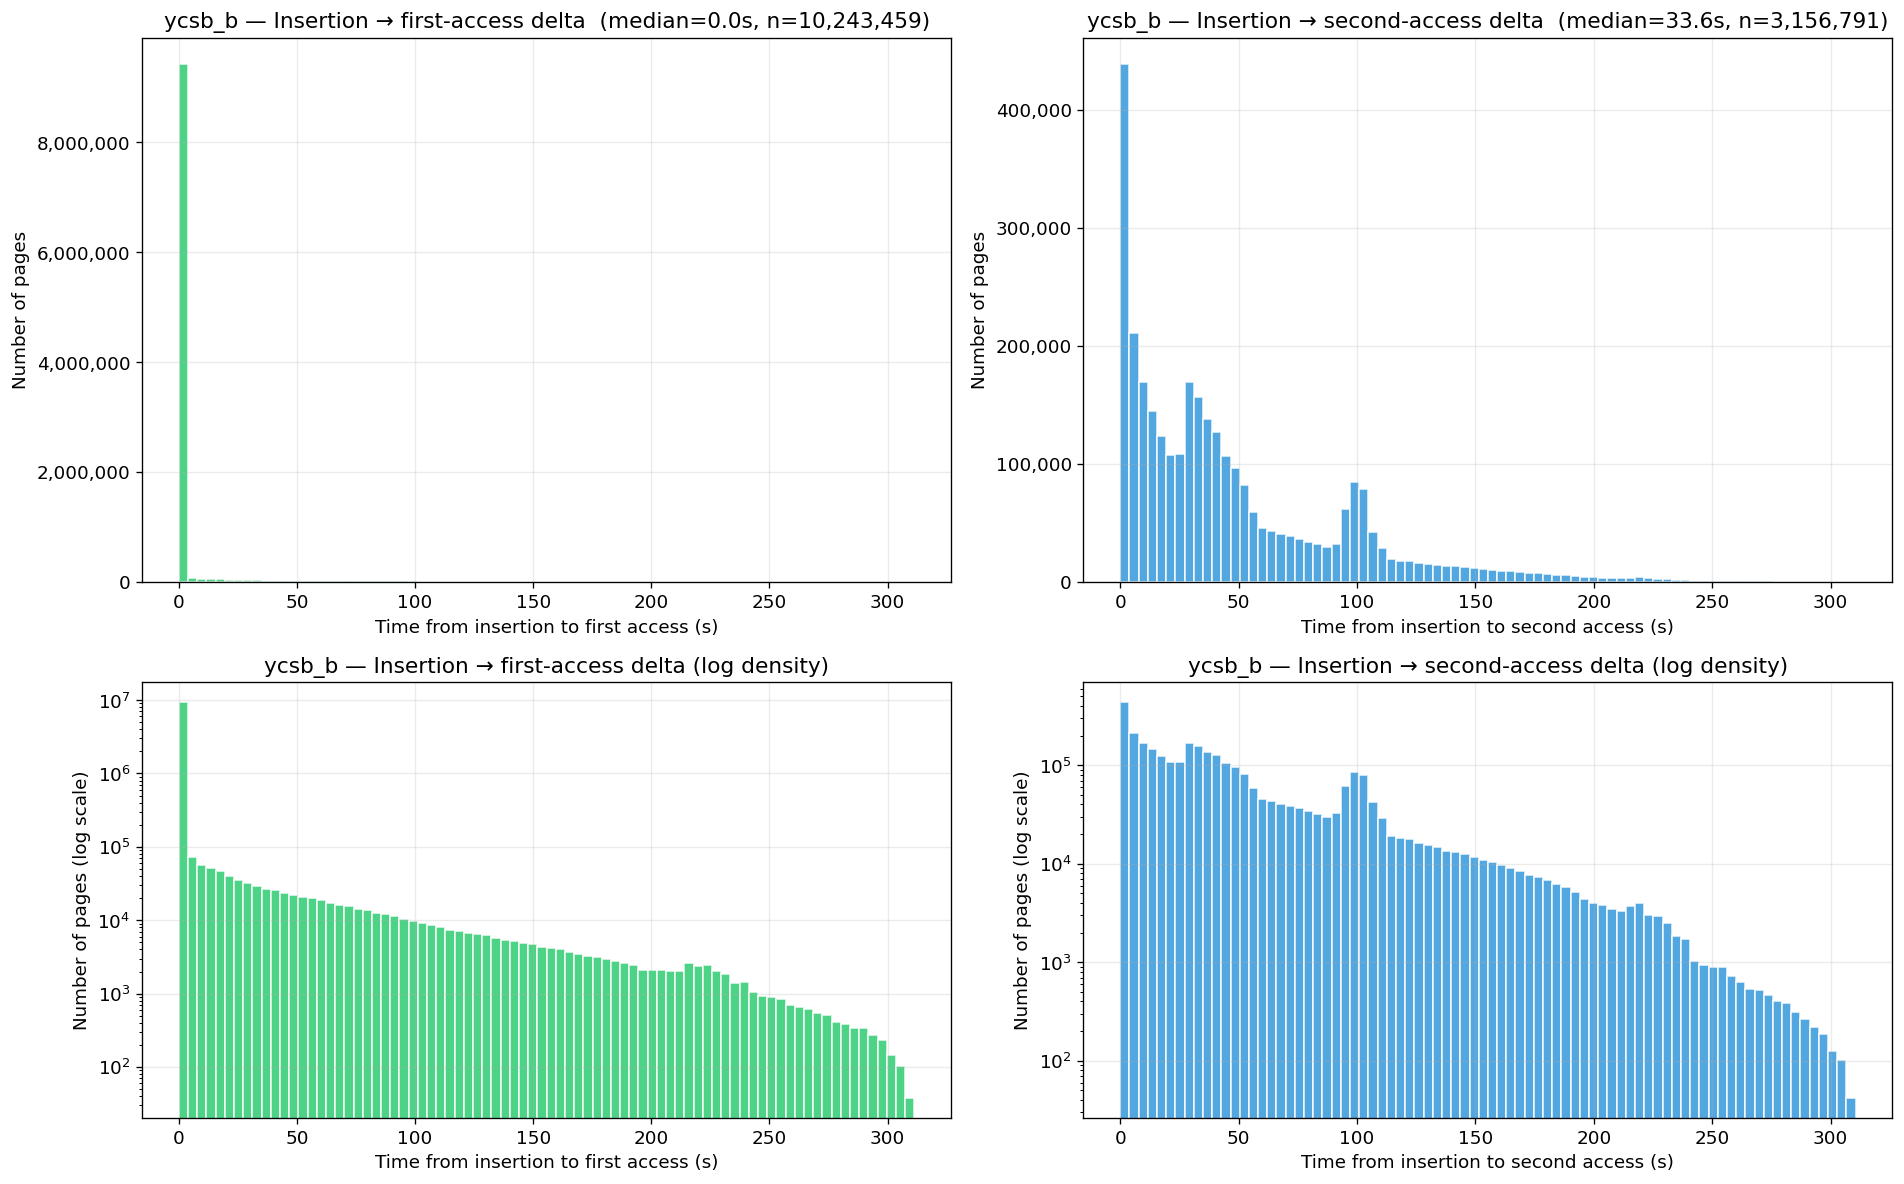


  Percentile    1st-access Δ    2nd-access Δ
--------------------------------------------
        1%ile           0.0s           0.0s
        5%ile           0.0s           0.4s
       10%ile           0.0s           2.1s
       25%ile           0.0s          10.9s
       50%ile           0.0s          33.6s
       75%ile           0.0s          69.8s
       90%ile           0.1s         108.8s
       95%ile          26.8s         144.1s
       99%ile         128.5s         209.9s


In [27]:
# ---- Dual-panel: first-access delta + second-access delta histograms -------
fig, axes = plt.subplots(2, 2, figsize=(16, 10),
                         gridspec_kw={"height_ratios": [1, 0.8]})

# ── Top-left: first-access delta histogram (linear x) ────────────────────
ax = axes[0, 0]
ax.hist(first_deltas, bins=80, color="#2ecc71", edgecolor="white", alpha=0.85)
ax.set_xlabel("Time from insertion to first access (s)")
ax.set_ylabel("Number of pages")
ax.set_title(f"{WORKLOAD} — Insertion → first-access delta  "
             f"(median={np.median(first_deltas):.1f}s, n={len(first_deltas):,})")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(True, alpha=0.25)

# ── Top-right: second-access delta histogram (linear x) ──────────────────
ax = axes[0, 1]
ax.hist(valid_second, bins=80, color="#3498db", edgecolor="white", alpha=0.85)
ax.set_xlabel("Time from insertion to second access (s)")
ax.set_ylabel("Number of pages")
ax.set_title(f"{WORKLOAD} — Insertion → second-access delta  "
             f"(median={np.median(valid_second):.1f}s, n={len(valid_second):,})")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(True, alpha=0.25)

# ── Bottom-left: linear x, log y first-access delta ──────────────────────
ax = axes[1, 0]
ax.hist(first_deltas, bins=80, color="#2ecc71",
        edgecolor="white", alpha=0.85)
ax.set_yscale("log")
ax.set_xlabel("Time from insertion to first access (s)")
ax.set_ylabel("Number of pages (log scale)")
ax.set_title(f"{WORKLOAD} — Insertion → first-access delta (log density)")
ax.grid(True, alpha=0.25)

# ── Bottom-right: linear x, log y second-access delta ────────────────────
ax = axes[1, 1]
ax.hist(valid_second, bins=80, color="#3498db",
        edgecolor="white", alpha=0.85)
ax.set_yscale("log")
ax.set_xlabel("Time from insertion to second access (s)")
ax.set_ylabel("Number of pages (log scale)")
ax.set_title(f"{WORKLOAD} — Insertion → second-access delta (log density)")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# ── Percentile summary ────────────────────────────────────────────────────
print(f"\n{'Percentile':>12s}  {'1st-access Δ':>14s}  {'2nd-access Δ':>14s}")
print("-" * 44)
for pct in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    f = np.percentile(first_deltas, pct)
    s = np.percentile(valid_second, pct)
    print(f"{pct:>9}%ile  {f:>12.1f}s  {s:>12.1f}s")

  ... 1,371,803/13,718,036 insertions processed (10%)
  ... 2,743,606/13,718,036 insertions processed (20%)
  ... 4,115,409/13,718,036 insertions processed (30%)
  ... 5,487,212/13,718,036 insertions processed (40%)
  ... 6,859,015/13,718,036 insertions processed (50%)
  ... 8,230,818/13,718,036 insertions processed (60%)
  ... 9,602,621/13,718,036 insertions processed (70%)
  ... 12,346,227/13,718,036 insertions processed (90%)

Insertions with ≥1 subsequent access: 10,243,459 / 13,718,036
Insertions with ≥2 subsequent accesses: 3,156,791 / 13,718,036
First-access delta  — median: 0.002s  max: 311.3s
Second-access delta — median: 33.614s  max: 310.5s


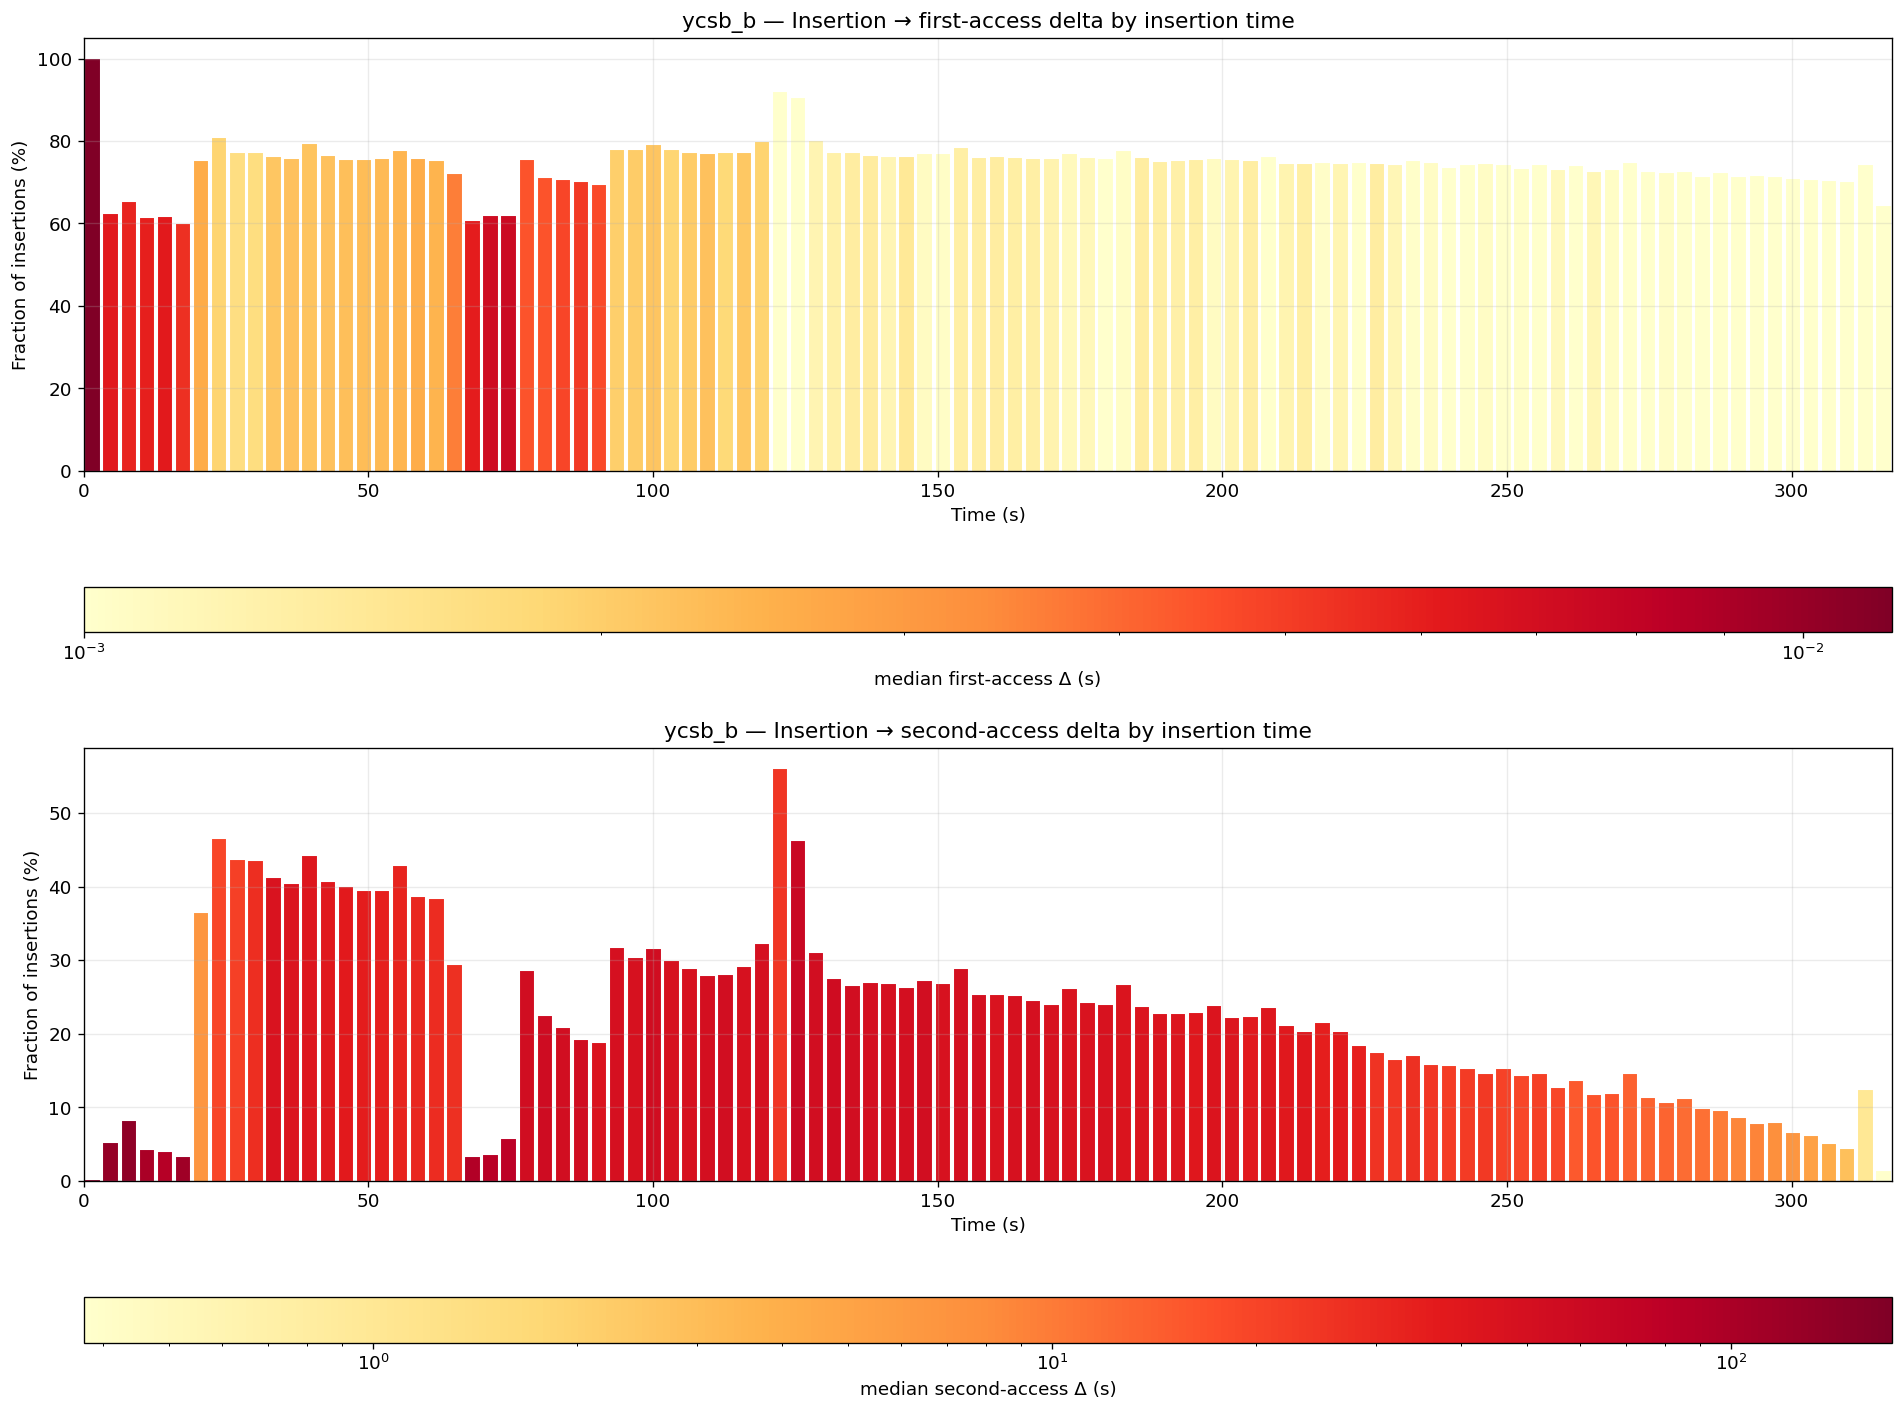

In [28]:
# ============================================================================
# Build aligned (insertion_ts, delta) pairs for heatmaps.
# first_deltas / valid_second don't include insertion timestamps — rebuild.
# ============================================================================
from matplotlib.colors import LogNorm, Normalize

ins_ts_first = []; first_d_vals = []   # insertion ts + first-access delta
ins_ts_second = []; second_d_vals = [] # insertion ts + second-access delta
N = len(insertion)
chunk = max(1, N // 10)
for i in range(N):
    key = (int(insertion["dm"][i]), int(insertion["dn"][i]),
           int(insertion["in"][i]), int(insertion["ix"][i]))
    ins_ts_ns = int(insertion["ts"][i])
    ts_arr = page_access_ts.get(key)
    if ts_arr is None:
        continue
    pos = np.searchsorted(ts_arr, ins_ts_ns, side="right")
    if pos < len(ts_arr):
        ins_ts_first.append(ins_ts_ns)
        first_d_vals.append(float(ts_arr[pos] - ins_ts_ns) / 1e9)
        if pos + 1 < len(ts_arr):
            ins_ts_second.append(ins_ts_ns)
            second_d_vals.append(float(ts_arr[pos + 1] - ins_ts_ns) / 1e9)
    if (i + 1) % chunk == 0:
        print(f"  ... {i+1:,}/{N:,} insertions processed ({(i+1)/N*100:.0f}%)")

its_first = np.array(ins_ts_first, dtype=np.uint64)
fd_vals = np.array(first_d_vals)
its_second = np.array(ins_ts_second, dtype=np.uint64)
sd_vals = np.array(second_d_vals)

t0_s = min(insertion["ts"][0], access["ts"][0])
dur_s = (max(insertion["ts"].max(), access["ts"].max()) - t0_s) / 1e9
its_first_s = (its_first - t0_s) / 1e9
its_second_s = (its_second - t0_s) / 1e9
all_ins_s = (insertion["ts"] - t0_s) / 1e9

def _plot_ins_delta_heatmap(ax, ts_arr, delta_arr, all_ts, dur, title, cbar_label):
    n_bins = 100
    bin_edges = np.linspace(0, dur, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bar_width = (bin_edges[1] - bin_edges[0]) * 0.8
    fracs = np.zeros(n_bins)
    median_deltas = np.full(n_bins, np.nan)
    for i in range(n_bins):
        mask_all = (all_ts >= bin_edges[i]) & (all_ts < bin_edges[i + 1])
        mask_evt = (ts_arr >= bin_edges[i]) & (ts_arr < bin_edges[i + 1])
        n_all = mask_all.sum()
        n_evt = mask_evt.sum()
        fracs[i] = (n_evt / n_all * 100) if n_all > 0 else 0
        if n_evt > 0:
            bin_mask = (ts_arr >= bin_edges[i]) & (ts_arr < bin_edges[i + 1])
            median_deltas[i] = np.median(delta_arr[bin_mask])
    valid = ~np.isnan(median_deltas)
    if valid.any():
        norm = LogNorm(vmin=max(median_deltas[valid].min(), 1e-3), vmax=median_deltas[valid].max())
    else:
        norm = Normalize(vmin=0, vmax=1)
    ax.bar(bin_centers, fracs, width=bar_width,
           color=plt.cm.YlOrRd(norm(median_deltas)), edgecolor="white", linewidth=0.05)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Fraction of insertions (%)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0, dur)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.18, aspect=40)
    cbar.set_label(cbar_label)

print(f"\nInsertions with ≥1 subsequent access: {len(fd_vals):,} / {N:,}")
print(f"Insertions with ≥2 subsequent accesses: {len(sd_vals):,} / {N:,}")
print(f"First-access delta  — median: {np.median(fd_vals):.3f}s  max: {fd_vals.max():.1f}s")
print(f"Second-access delta — median: {np.median(sd_vals):.3f}s  max: {sd_vals.max():.1f}s")

# ── Figure: 2-row heatmaps ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
_plot_ins_delta_heatmap(axes[0], its_first_s, fd_vals, all_ins_s, dur_s,
    f"{WORKLOAD} — Insertion → first-access delta by insertion time",
    "median first-access Δ (s)")
_plot_ins_delta_heatmap(axes[1], its_second_s, sd_vals, all_ins_s, dur_s,
    f"{WORKLOAD} — Insertion → second-access delta by insertion time",
    "median second-access Δ (s)")
plt.tight_layout()
plt.show()

---
## 5. Timestamp Ordering Check — Do Accesses Ever Appear Before Insertions?

Small discreptancies in code execution time or clock time MIGHT cause an insertion to be logged as after an access. This cell builds per-page
timelines (sorted insertions, sorted accesses) and checks for cases where an
access timestamp is **slightly before** an insertion timestamp for the same
page — a "negative" delta that would indicate clock jitter or reordering.

In [29]:
# ============================================================================
# Build page → insertion-timestamps lookup (same structure as page_access_ts)
# ============================================================================

def build_insertion_ts_dict(records):
    """Return { (dm, dn, ino, ix): np.array(sorted_timestamps) }."""
    d = defaultdict(list)
    N = len(records)
    chunk = max(1, N // 10)
    for i in range(N):
        key = (int(records["dm"][i]), int(records["dn"][i]),
               int(records["in"][i]), int(records["ix"][i]))
        d[key].append(int(records["ts"][i]))
        if (i + 1) % chunk == 0:
            print(f"  ... {i+1:,}/{N:,} records processed ({(i+1)/N*100:.0f}%)")
    for k in d:
        d[k] = np.array(sorted(d[k]), dtype=np.uint64)
    return d

print("Building page → insertion-timestamp lookup ...")
page_insertion_ts = build_insertion_ts_dict(insertion)
print(f"Done — {len(page_insertion_ts):,} unique pages indexed.")

# ============================================================================
# For every page with both insertions and accesses, check the gap between
# each insertion and the nearest access *before* it.  Also track:
#   - anomalous_ins_ts: insertion timestamps where an access appeared right before
#   - reinsertion data: pages inserted > 1 time
# ============================================================================
negative_deltas_ns = []
anomalous_ins_ts = []      # insertion timestamps with an access right before
n_pages_both = 0
n_insertions_with_access_before = 0
n_insertions_total = 0

# Re-insertion tracking
reinsertion_pages = {}     # key -> list of insertion timestamps (only pages with >1 insertion)
page_insertion_counts = {} # key -> count
for key, its_arr in page_insertion_ts.items():
    if len(its_arr) > 1:
        reinsertion_pages[key] = its_arr
    page_insertion_counts[key] = len(its_arr)

for key in page_access_ts:
    its_arr = page_insertion_ts.get(key)
    if its_arr is None:
        continue
    n_pages_both += 1
    ats = page_access_ts[key]
    n_insertions_total += len(its_arr)
    for it in its_arr:
        pos = np.searchsorted(ats, int(it), side="left")
        if pos > 0:
            n_insertions_with_access_before += 1
            delta_ns = int(it) - int(ats[pos - 1])
            negative_deltas_ns.append(delta_ns)
            anomalous_ins_ts.append(int(it))

neg = np.array(negative_deltas_ns, dtype=np.int64)
anom_ts = np.array(anomalous_ins_ts, dtype=np.uint64)

# Re-insertion stats
n_reinserted = len(reinsertion_pages)
reins_all_ts = np.array([int(t) for arr in reinsertion_pages.values() for t in arr], dtype=np.uint64)
n_insertion_multi = sum(page_insertion_counts[k] for k in reinsertion_pages)

# Split re-insertions by ordinal for downstream plotting cells
first_ts = []; second_ts = []; third_plus_ts = []
gaps_all = []
for key, its_arr in reinsertion_pages.items():
    if len(its_arr) >= 1:
        first_ts.append(int(its_arr[0]))
    if len(its_arr) >= 2:
        second_ts.append(int(its_arr[1]))
    if len(its_arr) >= 3:
        for t in its_arr[2:]:
            third_plus_ts.append(int(t))
    for i in range(1, len(its_arr)):
        gaps_all.append(float(its_arr[i] - its_arr[i-1]) / 1e9)
gaps = np.array(gaps_all) if gaps_all else np.array([])

print(f"\nPages with both insertions & accesses: {n_pages_both:,}")
print(f"Total insertions checked              : {n_insertions_total:,}")
print(f"Insertions with access before         : {n_insertions_with_access_before:,} "
      f"({n_insertions_with_access_before/n_insertions_total*100:.2f}%)")
print(f"Pages re-inserted (≥2 insertions)     : {n_reinserted:,}  "
      f"({n_reinserted/len(page_insertion_ts)*100:.1f}% of all inserted pages)")
print(f"Total insertions on re-inserted pages : {n_insertion_multi:,}")

if len(neg) > 0:
    print(f"\nAccess-BEFORE-insertion deltas (ns):")
    print(f"  count : {len(neg):,}")
    print(f"  min   : {neg.min():,} ns  ({neg.min()/1e3:.3f} us)")
    print(f"  p1    : {np.percentile(neg, 1):,.0f} ns")
    print(f"  p10   : {np.percentile(neg, 10):,.0f} ns")
    print(f"  median: {np.median(neg):,.0f} ns")
    print(f"  p90   : {np.percentile(neg, 90):,.0f} ns")
    print(f"  max   : {neg.max():,} ns")
    within_1us = int(np.sum(neg < 1_000))
    within_1ms = int(np.sum(neg < 1_000_000))
    print(f"  < 1 us : {within_1us:,}  ({within_1us/len(neg)*100:.1f}%)")
    print(f"  < 1 ms : {within_1ms:,}  ({within_1ms/len(neg)*100:.1f}%)")

Building page → insertion-timestamp lookup ...
  ... 1,371,803/13,718,036 records processed (10%)
  ... 2,743,606/13,718,036 records processed (20%)
  ... 4,115,409/13,718,036 records processed (30%)
  ... 5,487,212/13,718,036 records processed (40%)
  ... 6,859,015/13,718,036 records processed (50%)
  ... 8,230,818/13,718,036 records processed (60%)
  ... 9,602,621/13,718,036 records processed (70%)
  ... 10,974,424/13,718,036 records processed (80%)
  ... 12,346,227/13,718,036 records processed (90%)
  ... 13,718,030/13,718,036 records processed (100%)
Done — 10,454,254 unique pages indexed.

Pages with both insertions & accesses: 7,973,460
Total insertions checked              : 11,190,872
Insertions with access before         : 2,916,486 (26.06%)
Pages re-inserted (≥2 insertions)     : 2,439,014  (23.3% of all inserted pages)
Total insertions on re-inserted pages : 5,702,796

Access-BEFORE-insertion deltas (ns):
  count : 2,916,486
  min   : 155,150 ns  (155.150 us)
  p1    : 104,5

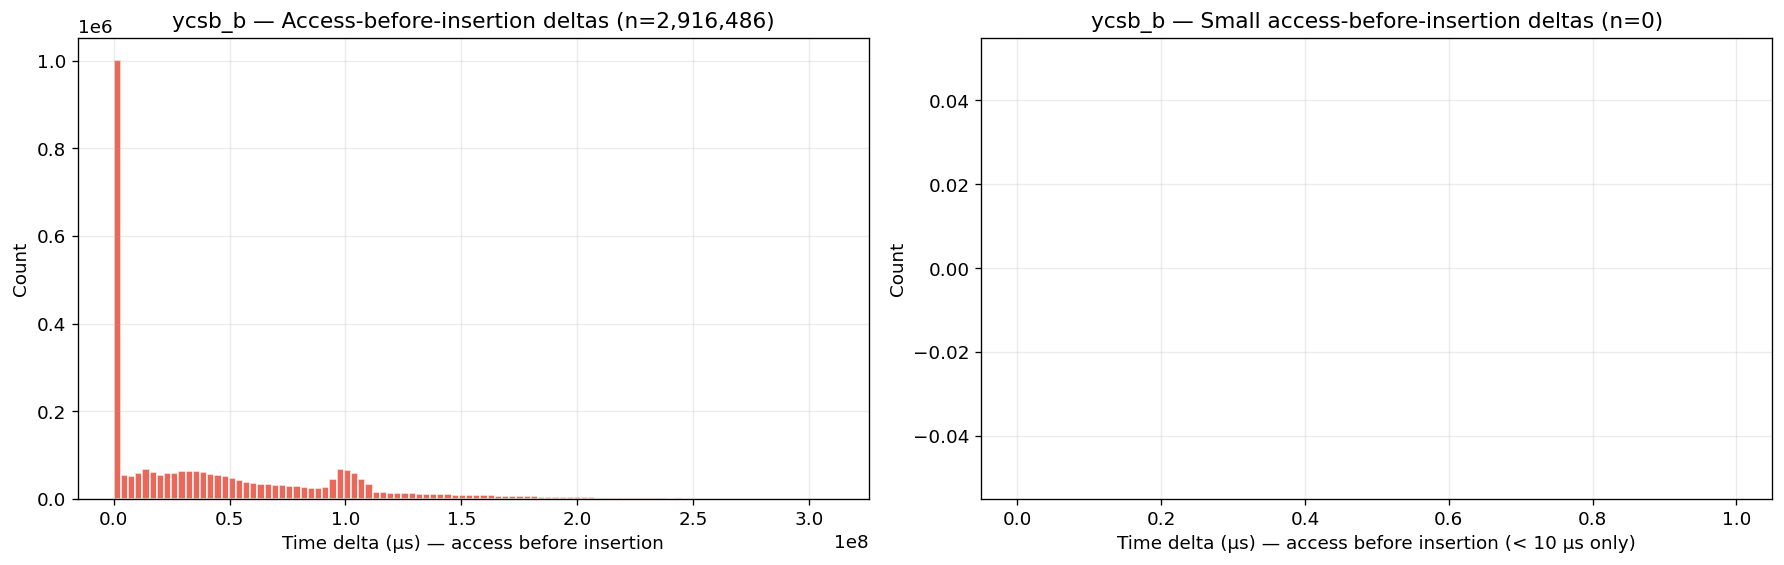

In [30]:
# ── Histograms of negative deltas ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.hist(neg / 1e3, bins=100, color="#e74c3c", edgecolor="white", alpha=0.85)
ax.set_xlabel("Time delta (µs) — access before insertion")
ax.set_ylabel("Count")
ax.set_title(f"{WORKLOAD} — Access-before-insertion deltas (n={len(neg):,})")
ax.grid(True, alpha=0.25)

ax = axes[1]
close = neg[neg < 10_000] / 1e3  # < 10 µs, in µs
ax.hist(close, bins=80, color="#e74c3c", edgecolor="white", alpha=0.85)
ax.set_xlabel("Time delta (µs) — access before insertion (< 10 µs only)")
ax.set_ylabel("Count")
ax.set_title(f"{WORKLOAD} — Small access-before-insertion deltas (n={len(close):,})")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

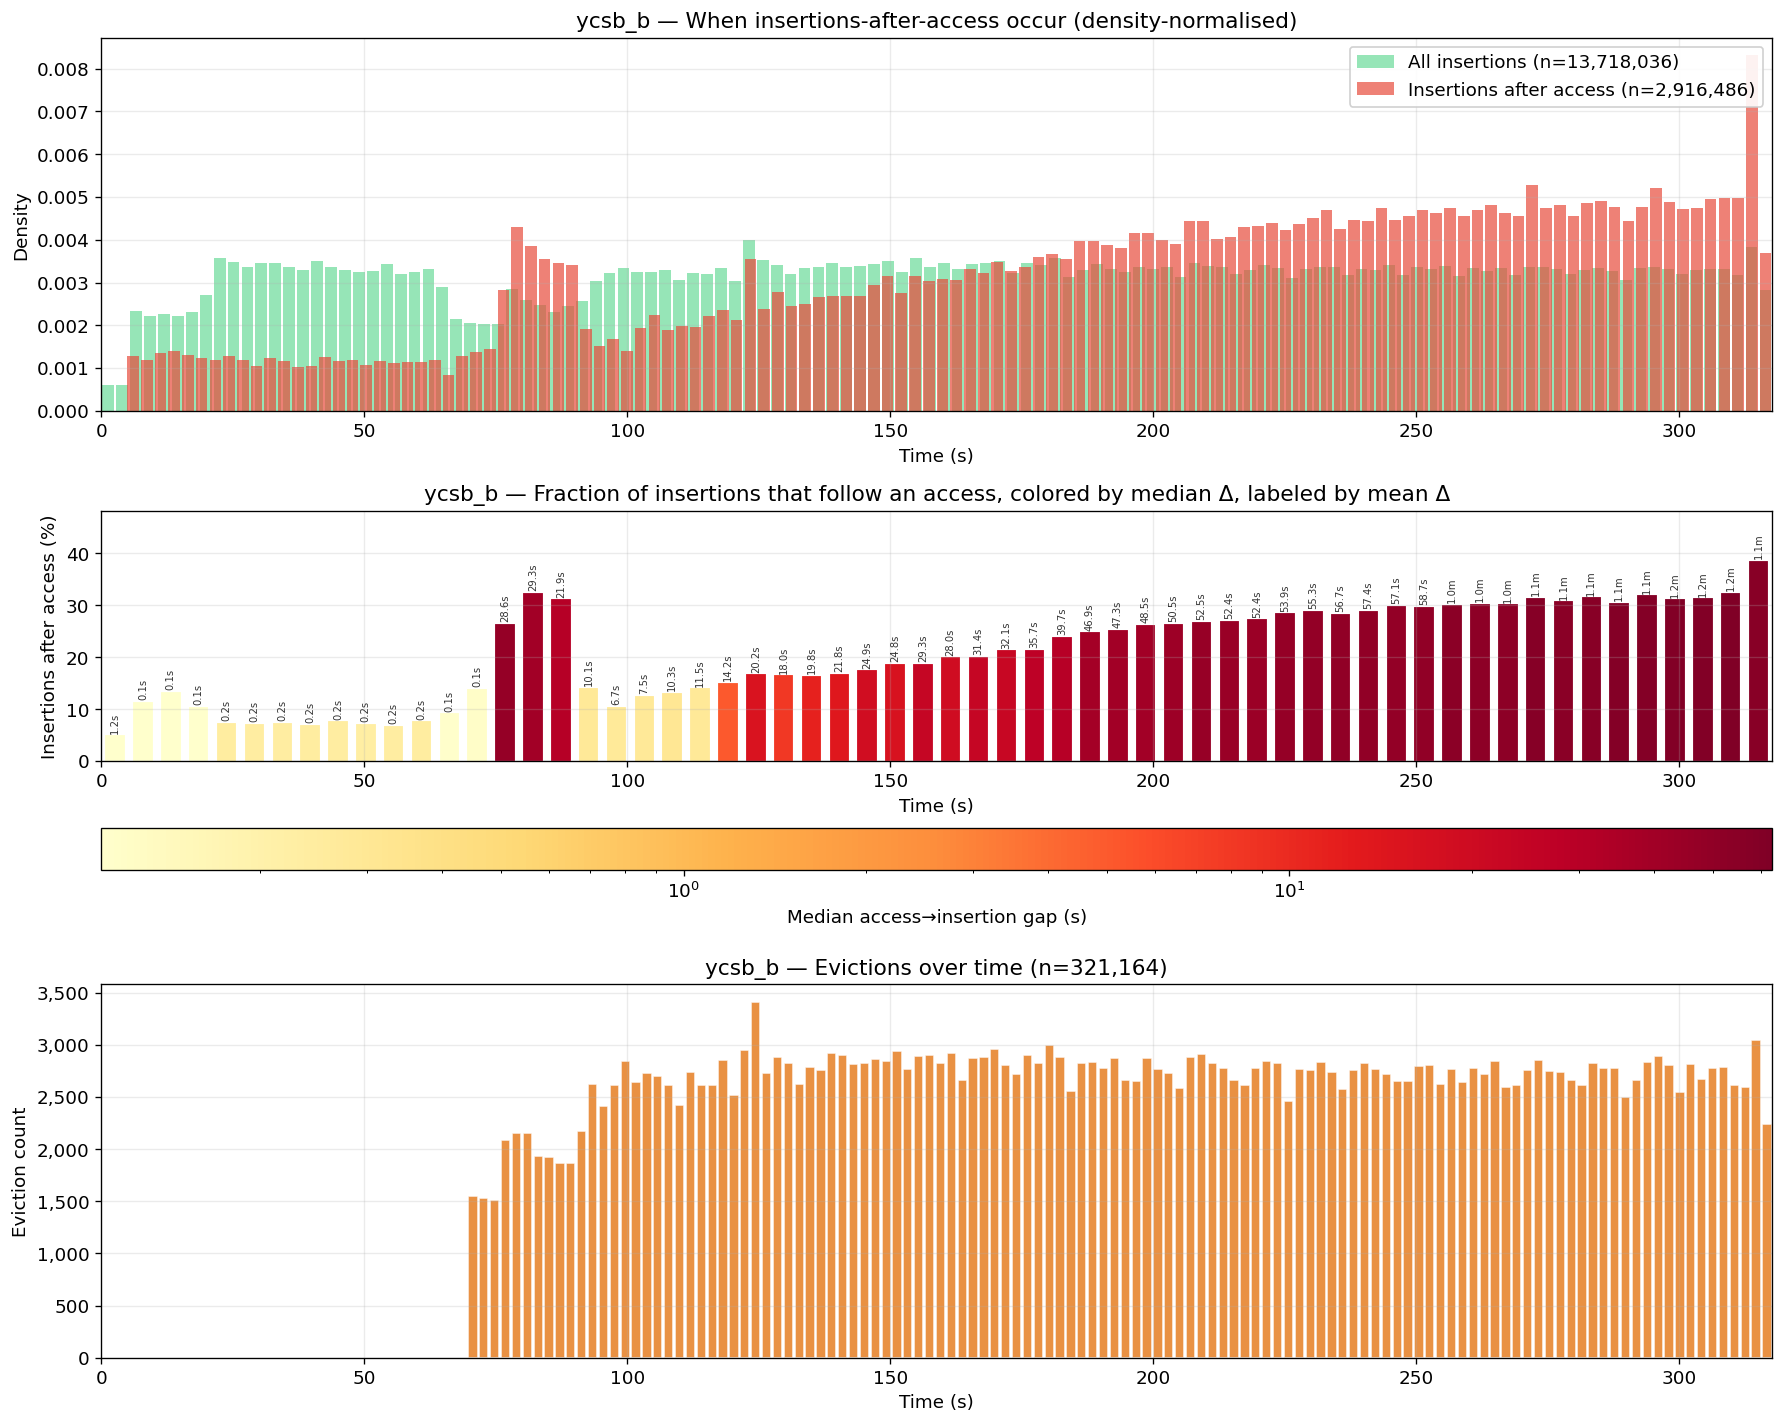

In [31]:
# ── When do insertions-after-access occur? ───────────────────────────────
from matplotlib.colors import LogNorm, Normalize

if len(anom_ts) > 0:
    t0_val = min(access["ts"][0], insertion["ts"][0], eviction["ts"][0])
    t_end = max(access["ts"].max(), insertion["ts"].max(), eviction["ts"].max())
    dur_s = (t_end - t0_val) / 1e9
    anom_s = (anom_ts - t0_val) / 1e9
    all_ins_s = (insertion["ts"] - t0_val) / 1e9
    evc_s = (eviction["ts"] - t0_val) / 1e9

    fig, axes = plt.subplots(3, 1, figsize=(15, 12))

    # ── Top: density overlay ─────────────────────────────────────────────
    ax = axes[0]
    ax.hist(all_ins_s, bins=120, alpha=0.5, density=True,
            color="#2ecc71", label=f"All insertions (n={len(all_ins_s):,})",
            rwidth=0.85)
    ax.hist(anom_s, bins=120, alpha=0.7, density=True,
            color="#e74c3c", label=f"Insertions after access (n={len(anom_s):,})",
            rwidth=0.85)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Density")
    ax.set_title(f"{WORKLOAD} — When insertions-after-access occur (density-normalised)")
    ax.legend(loc="upper right", framealpha=0.9)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0, dur_s)

    # ── Middle: fraction per bin, color-mapped by median access→insertion delta ─
    ax = axes[1]
    n_bins = 60
    bin_edges = np.linspace(0, all_ins_s.max(), n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bar_width = (bin_edges[1] - bin_edges[0]) * 0.7

    fracs = np.zeros(n_bins)
    mean_deltas = np.full(n_bins, np.nan)
    median_deltas = np.full(n_bins, np.nan)
    anom_mask_time = (anom_ts - t0_val) / 1e9
    for i in range(n_bins):
        mask_all = (all_ins_s >= bin_edges[i]) & (all_ins_s < bin_edges[i + 1])
        mask_anom = (anom_s >= bin_edges[i]) & (anom_s < bin_edges[i + 1])
        n_all = mask_all.sum()
        n_anom = mask_anom.sum()
        fracs[i] = (n_anom / n_all * 100) if n_all > 0 else 0
        if n_anom > 0:
            bin_anom_mask = (anom_mask_time >= bin_edges[i]) & (anom_mask_time < bin_edges[i + 1])
            mean_deltas[i] = neg[bin_anom_mask].mean() / 1e9
            median_deltas[i] = np.median(neg[bin_anom_mask]) / 1e9

    valid = ~np.isnan(median_deltas)
    if valid.any():
        norm = LogNorm(vmin=max(median_deltas[valid].min(), 1e-3),
                       vmax=median_deltas[valid].max())
    else:
        norm = Normalize(vmin=0, vmax=1)
    cmap = plt.cm.YlOrRd

    bars = ax.bar(bin_centers, fracs, width=bar_width,
                  color=cmap(norm(median_deltas)),
                  edgecolor="white", linewidth=0.1)

    # Annotate each bar with mean delta
    for i, (bar, frac) in enumerate(zip(bars, fracs)):
        if frac > 0 and not np.isnan(mean_deltas[i]):
            label = f"{mean_deltas[i]:.1f}s" if mean_deltas[i] < 60 else f"{mean_deltas[i]/60:.1f}m"
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + fracs.max() * 0.02,
                    label, ha="center", fontsize=6, rotation=90, color="#333")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Insertions after access (%)")
    ax.set_title(f"{WORKLOAD} — Fraction of insertions that follow an access, "
                 f"colored by median Δ, labeled by mean Δ")
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0, dur_s)
    ax.set_ylim(0, fracs.max() * 1.25)  # leave room for labels

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.18, aspect=40)
    cbar.set_label("Median access→insertion gap (s)")

    # ── Bottom: evictions ────────────────────────────────────────────────
    ax = axes[2]
    ax.hist(evc_s, bins=120, color="#e67e22", edgecolor="white", alpha=0.85,
            rwidth=0.85)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Eviction count")
    ax.set_title(f"{WORKLOAD} — Evictions over time (n={len(evc_s):,})")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0, dur_s)

    plt.tight_layout()
    plt.show()
else:
    print("No insertions-after-access to plot.")

Re-inserted pages: 2,439,014
  1st insertions          : 2,439,014
  2nd insertions          : 2,439,014
  1st→2nd gap — median: 52.2s  max: 311.3s


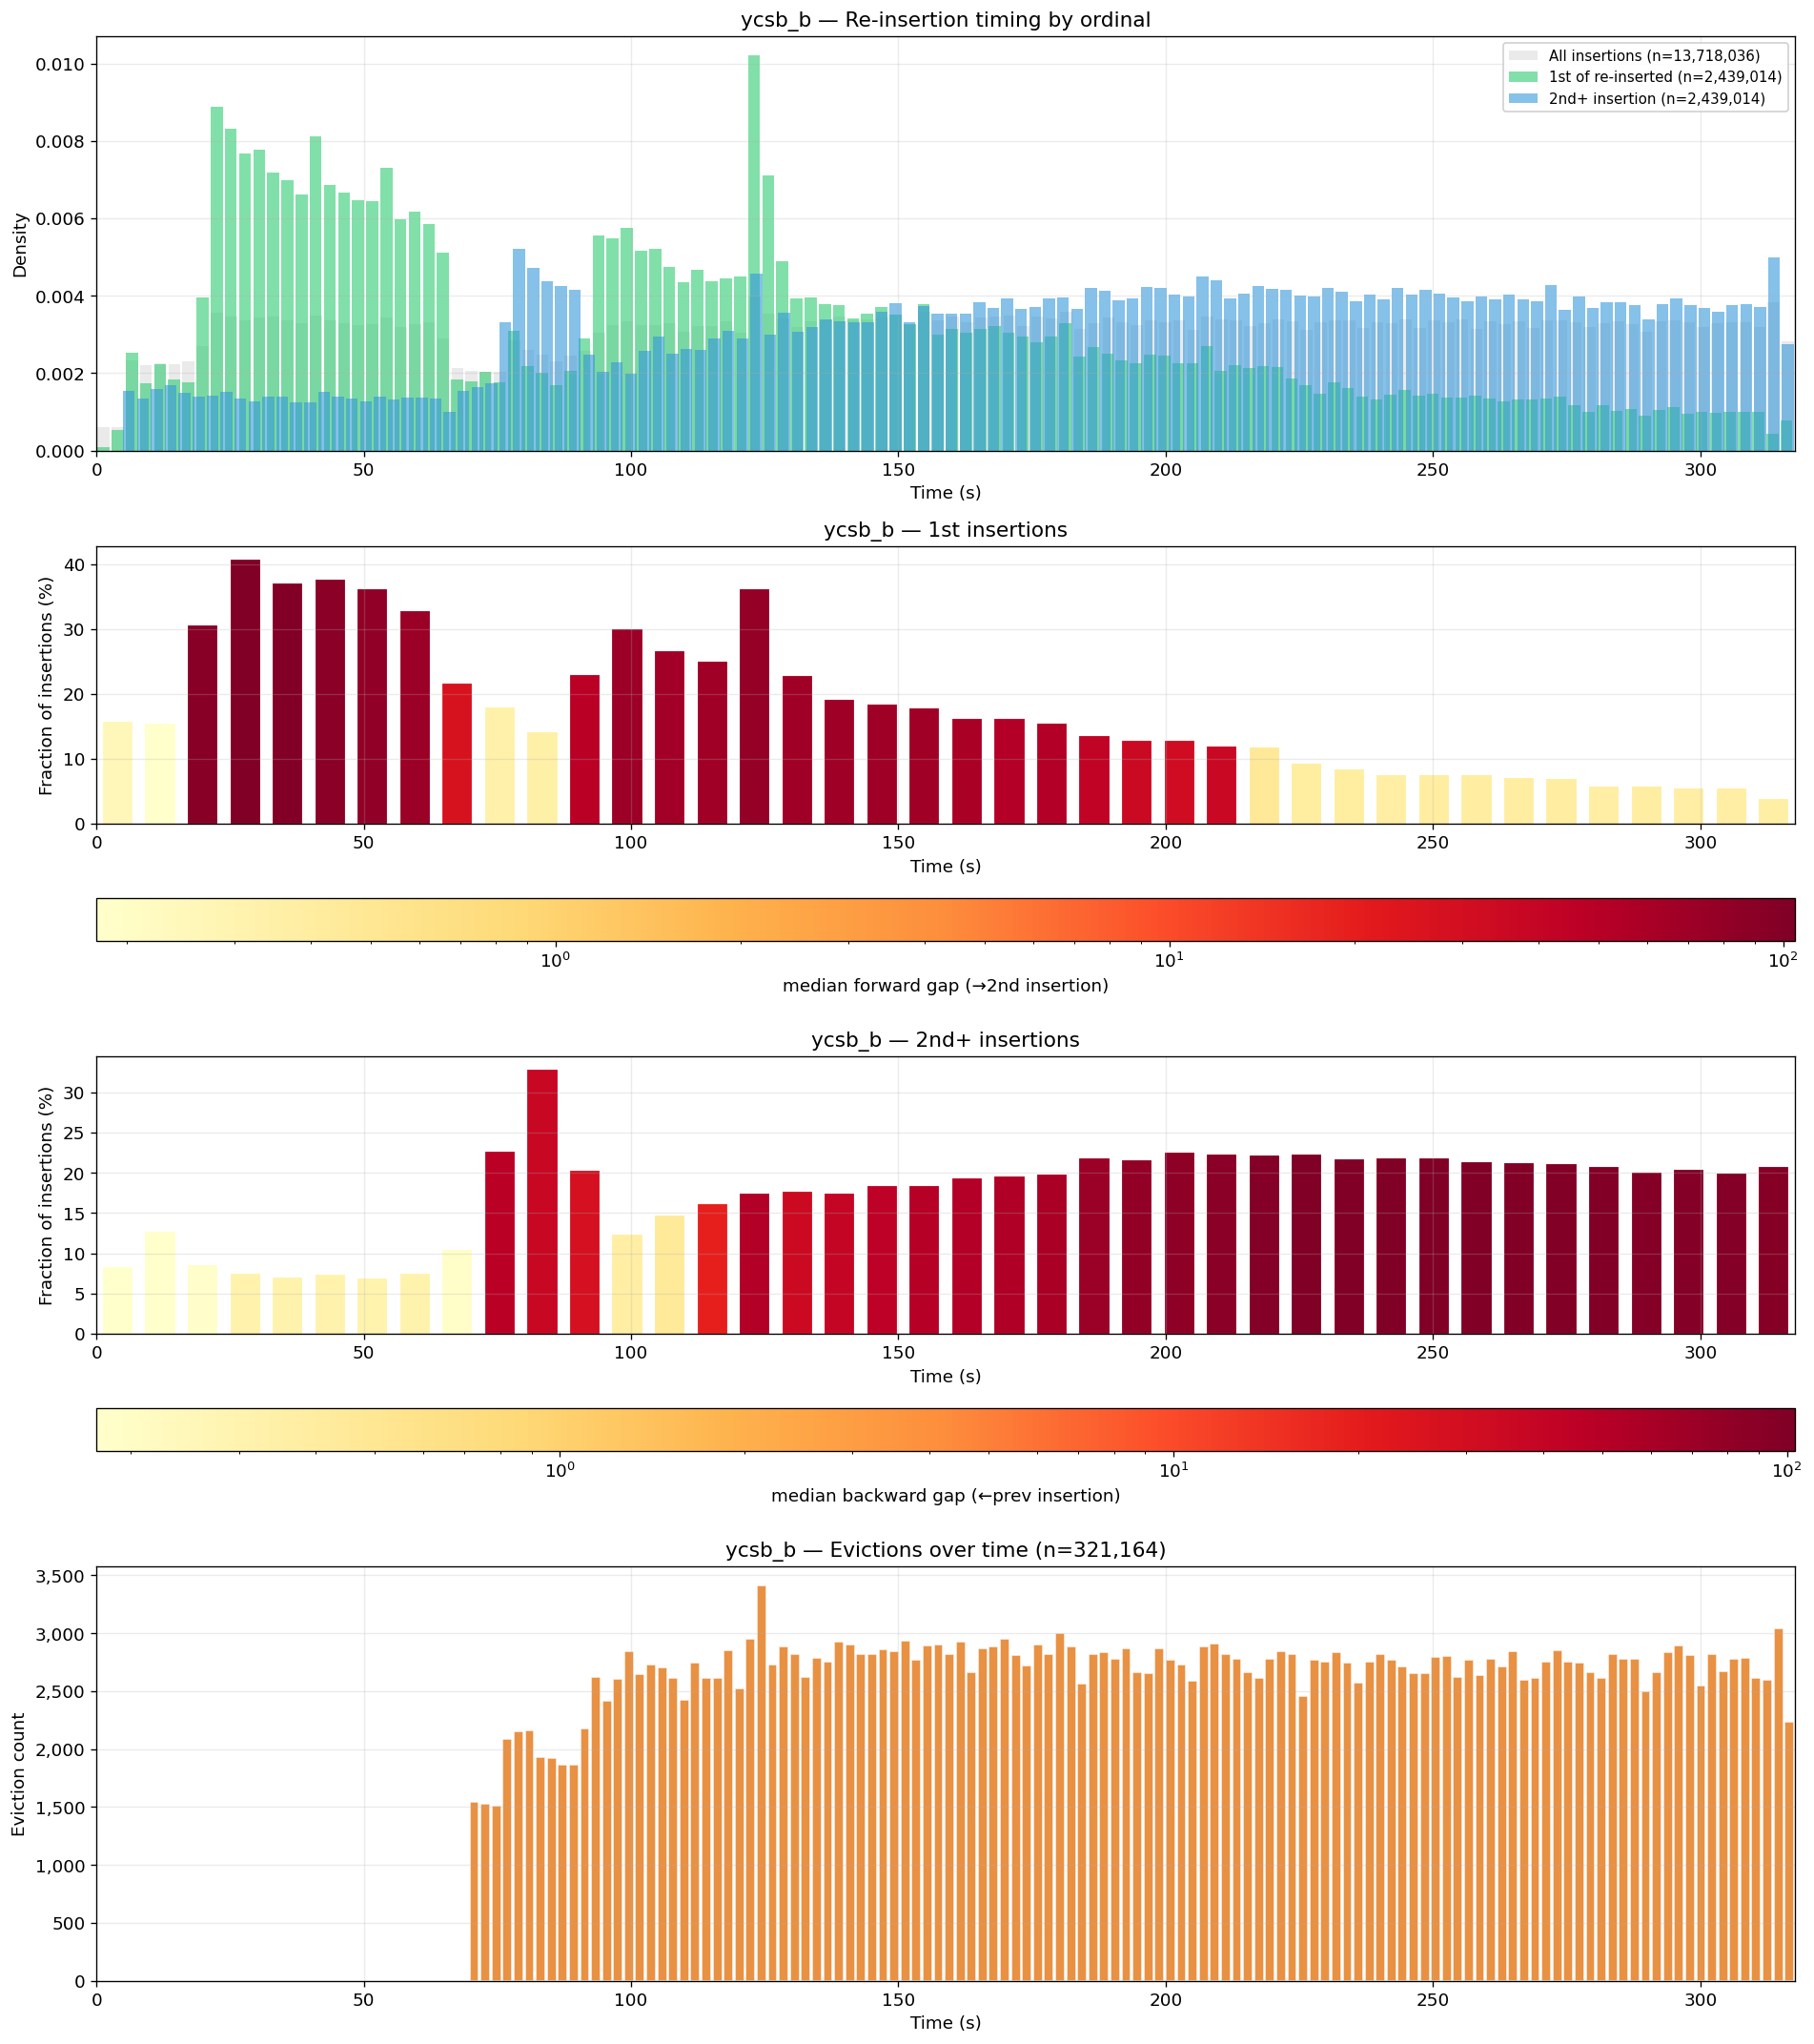

: 

In [ ]:
# ── When do re-insertions happen? ─────────────────────────────────────────
from matplotlib.colors import LogNorm, Normalize

def _plot_delta_heatmap(ax, ts_arr, delta_arr, all_ts, dur_s, title, cbar_label):
    """Color-mapped bar chart: fraction of events per time bin, colored by median delta."""
    n_bins = 40
    bin_edges = np.linspace(0, dur_s, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bar_width = (bin_edges[1] - bin_edges[0]) * 0.7

    fracs = np.zeros(n_bins)
    median_deltas = np.full(n_bins, np.nan)
    for i in range(n_bins):
        mask_all = (all_ts >= bin_edges[i]) & (all_ts < bin_edges[i + 1])
        mask_evt = (ts_arr >= bin_edges[i]) & (ts_arr < bin_edges[i + 1])
        n_all = mask_all.sum()
        n_evt = mask_evt.sum()
        fracs[i] = (n_evt / n_all * 100) if n_all > 0 else 0
        if n_evt > 0:
            bin_mask = (ts_arr >= bin_edges[i]) & (ts_arr < bin_edges[i + 1])
            median_deltas[i] = np.median(delta_arr[bin_mask])

    valid = ~np.isnan(median_deltas)
    if valid.any():
        norm = LogNorm(vmin=max(median_deltas[valid].min(), 1e-3),
                       vmax=median_deltas[valid].max())
    else:
        norm = Normalize(vmin=0, vmax=1)
    cmap = plt.cm.YlOrRd

    ax.bar(bin_centers, fracs, width=bar_width,
           color=cmap(norm(median_deltas)),
           edgecolor="white", linewidth=0.1)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Fraction of insertions (%)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0, dur_s)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.18, aspect=40)
    cbar.set_label(cbar_label)

if n_reinserted > 0:
    t0_val = min(insertion["ts"][0], access["ts"][0], eviction["ts"][0])
    t_end = max(insertion["ts"].max(), access["ts"].max(), eviction["ts"].max())
    dur_s = (t_end - t0_val) / 1e9
    evc_s = (eviction["ts"] - t0_val) / 1e9

    first_s  = (np.array(first_ts, dtype=np.uint64) - t0_val) / 1e9
    second_s = (np.array(second_ts, dtype=np.uint64) - t0_val) / 1e9 if second_ts else np.array([])
    all_ins_s2 = (insertion["ts"] - t0_val) / 1e9

    # Build aligned delta arrays: one gap per re-inserted page (1st→2nd)
    first_deltas_s = []
    second_deltas_s = []
    for key, its_arr in reinsertion_pages.items():
        if len(its_arr) >= 2:
            gap = float(its_arr[1] - its_arr[0]) / 1e9
            first_deltas_s.append(gap)
            second_deltas_s.append(gap)
    fdel = np.array(first_deltas_s)
    sdel = np.array(second_deltas_s)

    print(f"Re-inserted pages: {n_reinserted:,}")
    print(f"  1st insertions          : {len(first_s):,}")
    print(f"  2nd insertions          : {len(second_s):,}")
    print(f"  1st→2nd gap — median: {np.median(fdel):.1f}s  max: {fdel.max():.1f}s")

    # ── Figure: 4-row layout ─────────────────────────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=(16, 18))
    ax_top, ax_mid1, ax_mid2, ax_bot = axes

    # ── Row 1: density overlay ───────────────────────────────────────────
    bins = 120
    ax_top.hist(all_ins_s2, bins=bins, alpha=0.4, density=True,
                color="#cccccc", label=f"All insertions (n={len(all_ins_s2):,})",
                rwidth=0.85)
    ax_top.hist(first_s, bins=bins, alpha=0.6, density=True,
                color="#2ecc71", label=f"1st of re-inserted (n={len(first_s):,})",
                rwidth=0.85)
    ax_top.hist(second_s, bins=bins, alpha=0.6, density=True,
                color="#3498db", label=f"2nd+ insertion (n={len(second_s):,})",
                rwidth=0.85)
    ax_top.set_xlabel("Time (s)")
    ax_top.set_ylabel("Density")
    ax_top.set_title(f"{WORKLOAD} — Re-insertion timing by ordinal")
    ax_top.legend(loc="upper right", framealpha=0.9, fontsize=9)
    ax_top.grid(True, alpha=0.25)
    ax_top.set_xlim(0, dur_s)

    # ── Row 2: heatmap — 1st insertions colored by forward gap ───────────
    _plot_delta_heatmap(ax_mid1, first_s, fdel, all_ins_s2, dur_s,
                        f"{WORKLOAD} — 1st insertions",
                        "median forward gap (→2nd insertion)")

    # ── Row 3: heatmap — 2nd insertions colored by backward gap ──────────
    _plot_delta_heatmap(ax_mid2, second_s, sdel, all_ins_s2, dur_s,
                        f"{WORKLOAD} — 2nd+ insertions",
                        "median backward gap (←prev insertion)")

    # ── Row 4: evictions ─────────────────────────────────────────────────
    ax_bot.hist(evc_s, bins=120, color="#e67e22", edgecolor="white",
                alpha=0.85, rwidth=0.85)
    ax_bot.set_xlabel("Time (s)")
    ax_bot.set_ylabel("Eviction count")
    ax_bot.set_title(f"{WORKLOAD} — Evictions over time (n={len(evc_s):,})")
    ax_bot.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax_bot.grid(True, alpha=0.25)
    ax_bot.set_xlim(0, dur_s)

    plt.tight_layout()
    plt.show()
else:
    print("No re-inserted pages found.")

### Interpretation notes

- **Insertion-position reaccess**: measures whether pages inserted early in the
  workload are more (or less) likely to be accessed later.  A downward slope
  means earlier insertions are "hotter" — they have more time to be reaccessed.
  A flat line means insertion order carries no signal about future reuse.

- **First-access-position reaccess**: measures the same but anchored on the
  page's first access time.  Pages that appear early in the access stream have
  more opportunity for subsequent accesses, so a downward slope is expected;
  the steepness tells you how concentrated reuse is in early-arriving pages.

- Both metrics are **forward-looking only**: we only count accesses that occur
  *after* the reference event (insertion or first access).